Serial No. – Her öğrenciye ait benzersiz sıra numarası.

GRE Score – Öğrencinin GRE sınavından aldığı puan (0-340).

TOEFL Score – TOEFL sınavından alınan puan (0-120).

University Rating – Başvuru yapılan üniversitenin derecelendirmesi (1-5 arası).

SOP – Statement of Purpose (niyet mektubu) kalitesi (1-5 arası).

LOR – Referans mektubu gücü, genellikle danışmanlar tarafından değerlendirilir (1-5 arası).

CGPA – Mezuniyet not ortalaması (10 üzerinden).

Research – Araştırma deneyimi (0: yok, 1: var).

Chance of Admit – Kabul edilme olasılığı (0 ile 1 arasında tahmin edilen değer).  (label)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
import seaborn as sns



In [ ]:
file_path = '/content/drive/MyDrive/Logistic_Regression/Admission_Predict.csv'
data = pd.read_csv(file_path)


d

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


tüm değerler numerik şekilde. eksik değerimiz yok :)

In [ ]:
display(data.head())

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


admit ondalık sayı olarak verilmiş biz bunu 1 veya 0 a çevireceğiz

In [ ]:
data.shape

(400, 9)

In [ ]:
display(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


None

her şey numerik ve eksik değerimiz yok


In [ ]:
data.isnull().sum()

,0
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


In [ ]:
# Hedef değişkeni 0 ve 1 olarak sınıflandıralım
data["Chance of Admit Binary"] = (data["Chance of Admit "] >= 0.75).astype(int)

# data = data.drop(columns=["Chance of Admit "]) #### aşağıda kullanacağım şeylerden dolayı drop etmekten vazgeçtim

In [ ]:
display(data.head())

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit,Chance of Admit Binary
0,1,337,118,4,4.5,4.5,9.65,1,0.92,1
1,2,324,107,4,4.0,4.5,8.87,1,0.76,1
2,3,316,104,3,3.0,3.5,8.00,1,0.72,0
3,4,322,110,3,3.5,2.5,8.67,1,0.80,1
4,5,314,103,2,2.0,3.0,8.21,0,0.65,0


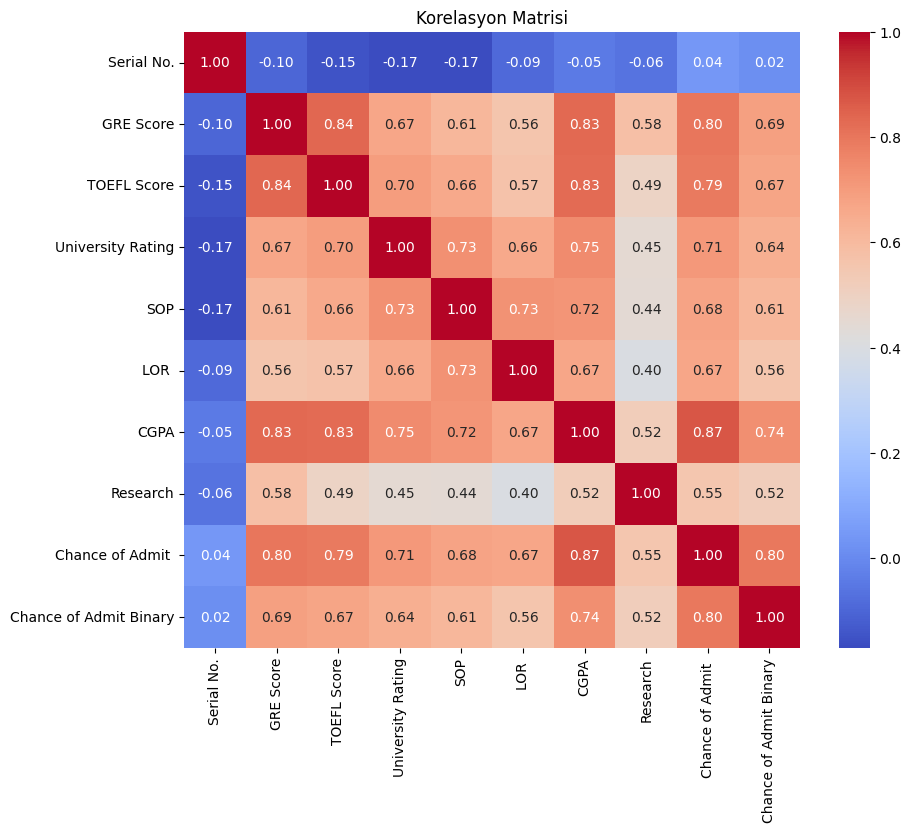

In [ ]:


# Korelasyon matrisini oluştur
corr_matrix = data.corr(numeric_only=True)

# Isı haritası ile görselleştir
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Korelasyon Matrisi")
plt.show()


korelasyonu yüksek olan veriler var. vif e de bakmak lazım

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# v ye atadık bunları
V = add_constant(data[["GRE Score", "TOEFL Score", "University Rating", "SOP", "LOR ", "CGPA", "Research"]])

# VIF hesaplaması
vif_data = pd.DataFrame()
vif_data["Variable"] = V.columns
vif_data["VIF"] = [variance_inflation_factor(V.values, i) for i in range(V.shape[1])]

print(vif_data)


            Variable          VIF
0              const  1529.672661
1          GRE Score     4.615516
2        TOEFL Score     4.288959
3  University Rating     2.919606
4                SOP     3.075504
5               LOR      2.431258
6               CGPA     5.207403
7           Research     1.543312


VIF değerleri 5 in üzerinde olmadığı için yüksek korelasyonlu olan gre toefl i çıkarmak istemedim. ancak LOR değerini çıkarttım. Çünkü binary ile olan korelasyonu da azdı hem de SOP ile olan korelasyonu düşük

x ve y olarak verileri ayırdık

In [ ]:
X = data[["GRE Score", "TOEFL Score", "University Rating", "SOP", "CGPA", "Research"]]
y = data["Chance of Admit Binary"]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 2. Eğitim/test setine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Sadece eğitim verisiyle scaler'ı fit et
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 4. Test verisini, eğitimden öğrenilen parametrelerle dönüştür
X_test_scaled = scaler.transform(X_test)


!!! Sigmoid fonksiyonu, lojistik regresyonda modelin hesapladığı lineer kombinasyonu alır ve onu 0 ile 1 arasında bir olasılığa dönüştürür.

Bu değer, örneğin "Bu öğrenci kabul edilir mi?" sorusuna, Evet olasılığı %85 gibi bir cevap verir.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Modeli oluşturup eğitelim

model = LogisticRegression(max_iter=1000, tol=1e-4, solver='lbfgs', random_state=42)
#model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_scaled, y_train.values.ravel())

# Test verisi ile tahmin yapalım
y_pred = model.predict(X_test_scaled)
print(f"Model {model.n_iter_[0]} iterasyonda durdu. Çünkü hata değişimi belirlenen tol={model.tol} eşiğinin altına düştü.")





Model 11 iterasyonda durdu. Çünkü hata değişimi belirlenen tol=0.0001 eşiğinin altına düştü.


**toleransa, çok düşük bir değer verdik bir sonraki log loss ile bir önceki log-loss arasındaki fark bu değer ise öğrenmeyi keser.**

In [ ]:
# Doğruluk oranı
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Doğruluk Oranı: {accuracy:.4f}")

# Sınıflandırma Raporu
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))

# Karmaşıklık Matrisi (Confusion Matrix)
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nKarmaşıklık Matrisi:")
print(conf_matrix)




Model Doğruluk Oranı: 0.9125

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92        47
           1       0.86      0.94      0.90        33

    accuracy                           0.91        80
   macro avg       0.91      0.92      0.91        80
weighted avg       0.92      0.91      0.91        80


Karmaşıklık Matrisi:
[[42  5]
 [ 2 31]]


PRECISION: TP / (TP + FP) --> Modelin 1 (pozitif) tahmin ettikleri arasında, gerçekten doğru olanların oranıdır.

RECALL: TP / (TP + FN) --> Gerçek pozitiflerin ne kadarını doğru yakaladığını gösterir.

f1 score: 2 * (Precision * Recall) / (Precision + Recall) --> Precision ve Recall'un dengeli bir ortalamasıdır.



bu modelin Hem doğruluk oranı yüksek hem de dengeli sonuçlar var.

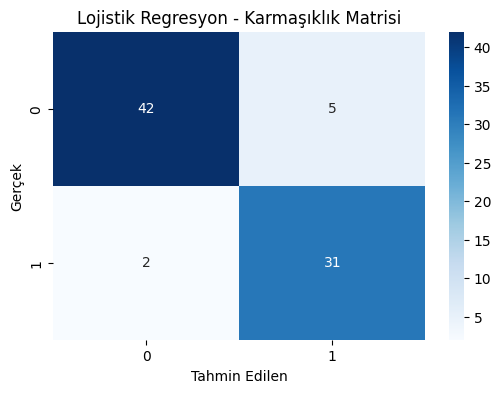

In [ ]:
# Karmaşıklık matrisini görselleştirelim
import seaborn as sns

plt.figure(figsize=(6, 4))
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek")
plt.title("Lojistik Regresyon - Karmaşıklık Matrisi")
plt.show()

Karmaşıklık matrisi, tahmin edilen ve gerçek değerler arasındaki ilişkileri tablo şeklinde gösterir

In [ ]:
# Test verisi için modelin tahmin ettiği olasılıkları alalım
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]  # Sadece 1 sınıfına ait olasılıkları alalım

# Gerçek değerler ve tahmin edilen olasılıkları içeren bir tablo oluşturalım
results_df = pd.DataFrame({
    "Gerçek Değer (Y)": y_test.values.flatten(),
    "Tahmin Edilen Kabul Olasılığı": y_pred_proba.round(4),
    "Tahmin (0 = Reddedildi, 1 = Kabul Edildi)": y_pred
})

# İlk 20 satırı gösterelim
display(results_df.head(20))


,Gerçek Değer (Y),Tahmin Edilen Kabul Olasılığı,"Tahmin (0 = Reddedildi, 1 = Kabul Edildi)"
0,0,0.0706,0
1,0,0.5318,1
2,1,0.9972,1
3,1,0.9483,1
4,0,0.0144,0
5,1,0.9967,1
6,0,0.0037,0
7,0,0.0031,0
8,0,0.0606,0
9,1,0.9635,1


gördüğümüz gibi bir değişkende gerçek değerle tahmin edilen değer arasında hata var.

In [ ]:
from sklearn.linear_model import SGDClassifier
import numpy as np

# SGDClassifier ile model oluştur (Stokastik Gradyan İnişi)
sgd_model = SGDClassifier(loss="log_loss", max_iter=1000, tol=1e-4, random_state=42, verbose=1)

# Modeli eğitim setinde eğit
sgd_model.fit(X_train_scaled, y_train.values.ravel())

# Eğitilen modelin ağırlıklarını ve bias değerini göster
print(f"\nSon Bias (b): {sgd_model.intercept_}")
print(f"Son Ağırlıklar (W): {sgd_model.coef_[:3]}")  # İlk 3 ağırlık

-- Epoch 1
Norm: 30.33, NNZs: 6, Bias: 4.733081, T: 320, Avg. loss: 3.139675
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 26.05, NNZs: 6, Bias: 4.177019, T: 640, Avg. loss: 2.055773
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 21.51, NNZs: 6, Bias: -1.082044, T: 960, Avg. loss: 2.069638
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 17.29, NNZs: 6, Bias: -1.969077, T: 1280, Avg. loss: 1.793101
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 14.40, NNZs: 6, Bias: 1.828578, T: 1600, Avg. loss: 1.484153
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 11.12, NNZs: 6, Bias: -1.148955, T: 1920, Avg. loss: 1.143791
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 10.85, NNZs: 6, Bias: 1.973502, T: 2240, Avg. loss: 1.177072
Total training time: 0.00 seconds.
-- Epoch 8
Norm: 9.62, NNZs: 6, Bias: -7.933019, T: 2560, Avg. loss: 0.904333
Total training time: 0.00 seconds.
-- Epoch 9
Norm: 9.47, NNZs: 6, Bias: 0.277034, T: 2880, Avg. loss: 0.918847
Total training time

Model erken durmayı epoch 26 da tetikledi çünkü loss önceki 5 epoch boyunca 0.001'den daha az iyileşti. Yani eğitim hatası farkı çok azaldığı için, 26 epoch sonra model öğrenmeyi durdurdu



Modelin Öğrendiği Ağırlıklar (W):
Bu değerler featureslerin model tahminine olan katkısını temsil eder

Bias: modelin öğrenme yeteneğini artırmak için kullanılan bir sabit değerdir.

loss umuz arada yükselsede genel olarak düşmektedir. özellikle derin öğrenmede buna bakılır. en idealimiz epoch 54.

In [ ]:
model_l2 = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000)
model_l2.fit(X_train_scaled, y_train)

y_pred_l2 = model_l2.predict(X_test_scaled)

print("L2 Regularizasyon Sonuçları (Ridge):")
print("Doğruluk: {:.2f}%".format(accuracy_score(y_test, y_pred_l2) * 100))
print(classification_report(y_test, y_pred_l2))

# Ağırlıkları görelim
pd.DataFrame(model_l2.coef_[0], index=X.columns, columns=["L2 Ağırlık"])


L2 Regularizasyon Sonuçları (Ridge):
Doğruluk: 91.25%
              precision    recall  f1-score   support

           0       0.95      0.89      0.92        47
           1       0.86      0.94      0.90        33

    accuracy                           0.91        80
   macro avg       0.91      0.92      0.91        80
weighted avg       0.92      0.91      0.91        80



,L2 Ağırlık
GRE Score,0.715071
TOEFL Score,0.289963
University Rating,0.334886
SOP,0.551841
CGPA,1.837035
Research,0.417600


L2 ridge ile deniyoruz

In [ ]:
model_l1 = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)
model_l1.fit(X_train_scaled, y_train)

y_pred_l1 = model_l1.predict(X_test_scaled)

print("L1 Regularizasyon Sonuçları (Lasso):")
print("Doğruluk: {:.2f}%".format(accuracy_score(y_test, y_pred_l1) * 100))
print(classification_report(y_test, y_pred_l1))

# Ağırlıkları görelim
pd.DataFrame(model_l1.coef_[0], index=X.columns, columns=["L1 Ağırlık"])


L1 Regularizasyon Sonuçları (Lasso):
Doğruluk: 91.25%
              precision    recall  f1-score   support

           0       0.95      0.89      0.92        47
           1       0.86      0.94      0.90        33

    accuracy                           0.91        80
   macro avg       0.91      0.92      0.91        80
weighted avg       0.92      0.91      0.91        80



,L1 Ağırlık
GRE Score,0.681704
TOEFL Score,0.220673
University Rating,0.299072
SOP,0.511833
CGPA,2.021846
Research,0.411246


l1 lasso ile deniyoruz

**l2 ridge ve l1 lasso ekleyerek tekrar bakmak istedim. Değerler aynı çıktı. Sebebi overfitting olmaması, datanın temiz ve az olması olabilir.** ancak ağırlıklar değişti

--------------------------------------------------------------------------------

**şimdi  hedef değişkeni 0.8 ve 0.7 den büyükse 1 e eşitleyip iki farklı şekilde tekrar deneyip sonuçlarına bakıyoruz.  geri kalan her şey aynı.**

In [ ]:
# Hedef değişkeni 0 ve 1 olarak sınıflandıralım
data["Chance of Admit Binary2"] = (data["Chance of Admit "] >= 0.8).astype(int)


In [ ]:
X = data[["GRE Score", "TOEFL Score", "University Rating", "SOP", "CGPA", "Research"]]
y = data["Chance of Admit Binary2"]

# 2. Eğitim/test setine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Sadece eğitim verisiyle scaler'ı fit et
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 4. Test verisini, eğitimden öğrenilen parametrelerle dönüştür
X_test_scaled = scaler.transform(X_test)


# Modeli oluşturup eğitelim

model = LogisticRegression(max_iter=1000, tol=1e-4, solver='lbfgs', random_state=42)
#model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_scaled, y_train.values.ravel())

# Test verisi ile tahmin yapalım
y_pred = model.predict(X_test_scaled)
print(f"Model {model.n_iter_[0]} iterasyonda durdu. Çünkü hata değişimi belirlenen tol={model.tol} eşiğinin altına düştü.")





Model 12 iterasyonda durdu. Çünkü hata değişimi belirlenen tol=0.0001 eşiğinin altına düştü.


In [ ]:
# Doğruluk oranı
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Doğruluk Oranı: {accuracy:.4f}")

# Sınıflandırma Raporu
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))

# Karmaşıklık Matrisi (Confusion Matrix)
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nKarmaşıklık Matrisi:")
print(conf_matrix)




Model Doğruluk Oranı: 0.9625

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        51
           1       0.93      0.97      0.95        29

    accuracy                           0.96        80
   macro avg       0.96      0.96      0.96        80
weighted avg       0.96      0.96      0.96        80


Karmaşıklık Matrisi:
[[49  2]
 [ 1 28]]


sırada 0.7 ile deneme var


In [ ]:
# Hedef değişkeni 0 ve 1 olarak sınıflandıralım
data["Chance of Admit Binary3"] = (data["Chance of Admit "] >= 0.7).astype(int)


In [ ]:
X = data[["GRE Score", "TOEFL Score", "University Rating", "SOP", "CGPA", "Research"]]
y = data["Chance of Admit Binary3"]
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 2. Eğitim/test setine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Sadece eğitim verisiyle scaler'ı fit et
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 4. Test verisini, eğitimden öğrenilen parametrelerle dönüştür
X_test_scaled = scaler.transform(X_test)


# Modeli oluşturup eğitelim

model = LogisticRegression(max_iter=1000, tol=1e-4, solver='lbfgs', random_state=42)
#model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_scaled, y_train.values.ravel())

# Test verisi ile tahmin yapalım
y_pred = model.predict(X_test_scaled)
print(f"Model {model.n_iter_[0]} iterasyonda durdu. Çünkü hata değişimi belirlenen tol={model.tol} eşiğinin altına düştü.")





Model 9 iterasyonda durdu. Çünkü hata değişimi belirlenen tol=0.0001 eşiğinin altına düştü.


In [ ]:
# Doğruluk oranı
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Doğruluk Oranı: {accuracy:.4f}")

# Sınıflandırma Raporu
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))

# Karmaşıklık Matrisi (Confusion Matrix)
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nKarmaşıklık Matrisi:")
print(conf_matrix)




Model Doğruluk Oranı: 0.8625

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83        32
           1       0.89      0.88      0.88        48

    accuracy                           0.86        80
   macro avg       0.86      0.86      0.86        80
weighted avg       0.86      0.86      0.86        80


Karmaşıklık Matrisi:
[[27  5]
 [ 6 42]]


In [ ]:
# Test verisi için modelin tahmin ettiği olasılıkları alalım
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]  # Sadece 1 sınıfına ait olasılıkları alalım

# Gerçek değerler ve tahmin edilen olasılıkları içeren bir tablo oluşturalım
results_df = pd.DataFrame({
    "Gerçek Değer (Y)": y_test.values.flatten(),
    "Tahmin Edilen Kabul Olasılığı": y_pred_proba.round(4),
    "Tahmin (0 = Reddedildi, 1 = Kabul Edildi)": y_pred
})

# İlk 20 satırı gösterelim
display(results_df.head(20))


,Gerçek Değer (Y),Tahmin Edilen Kabul Olasılığı,"Tahmin (0 = Reddedildi, 1 = Kabul Edildi)"
0,0,0.2377,0
1,0,0.6675,1
2,1,0.9990,1
3,1,0.9740,1
4,0,0.0814,0
5,1,0.9987,1
6,0,0.0305,0
7,0,0.0607,0
8,1,0.3945,0
9,1,0.9778,1


0.7 de gördüğümüz gibi hatalar arttı. ancak 0.8 de olaylar farklı.

chance of admit'i 0.8 den itibaren 1 e eşitleyince modelimizin doğruluk oranı artıyor. Bunun sebebi 0.8 Eşiği daha katı sınıflandırmadır. Model bu azınlık sınıfı daha iyi öğreniyor.

modelin geliştirilmesi için, feature engineering yapılıp daha fazla özellik eklenebilir, Random Forest gibi farklı sınıflandırma algoritmaları denenebilir, overfitting varsa L2 (Ridge) veya L1 (Lasso) regularizasyon ile aşırı öğrenme engellenebilir, eşik değerler farklı değerlerle denenebilir.